# TSLA — Classification Models (Iteration 2)

**Walk-forward config:** train=63d, test=42d, no embargo  
**Target:** `target_direction` — next-day price direction (Down=-1, Flat=0, Up=1)  
**Threshold:** ±1.5% (moves smaller than 1.5% classified as Flat — ~3× SPY volatility)  
**Models:** Logistic Regression (C=0.1), Random Forest (100 trees)  
**Data:** `../data/TSLA_features.csv` (Yahoo Finance, 2015–2025, ~2,510 rows)

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

In [2]:
tsla_raw = pd.read_csv("../data/TSLA_features.csv", parse_dates=["date"], index_col="date")

print(f"TSLA: {len(tsla_raw):,} rows | {tsla_raw.index[0].date()} \u2192 {tsla_raw.index[-1].date()}")

TSLA: 2,515 rows | 2015-01-02 → 2024-12-30


In [3]:
FEATURES = [
    "daily_return", "weekly_return", "lag_return_1", "lag_return_3", "lag_return_5",
    "dist_from_ma21", "ma_cross",
    "macd_hist",
    "daily_range", "volatility_20", "bb_position",
    "volume_change", "volume_ratio",
    "rsi_14",
    "is_major_event", "is_earnings_week",
]

TRAIN_WINDOW = 63
TEST_WINDOW  = 42


def walk_forward_splits(df, train_window=TRAIN_WINDOW, test_window=TEST_WINDOW):
    splits = []
    n = len(df)
    start = 0
    while start + train_window + test_window <= n:
        train_idx = list(range(start, start + train_window))
        test_idx  = list(range(start + train_window, start + train_window + test_window))
        splits.append((train_idx, test_idx))
        start += test_window
    return splits


def prepare_data(df, target_col, train_idx, test_idx):
    X = df[FEATURES].values
    y = df[target_col].values
    X_train, y_train = X[train_idx], y[train_idx]
    X_test,  y_test  = X[test_idx],  y[test_idx]
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test, scaler

In [4]:
def run_logistic_regression(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("LOGISTIC REGRESSION \u2014 Predicting price direction")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, fold_coefs = [], [], []
    agg_cm, last_model = np.zeros((3, 3), dtype=int), None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_direction", train_idx, test_idx)
        model = LogisticRegression(max_iter=1000, C=0.1)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        report = classification_report(y_test, preds, output_dict=True, zero_division=0)
        fold_metrics.append({"fold": fold, "accuracy": accuracy_score(y_test, preds),
                              "precision": report["macro avg"]["precision"],
                              "recall": report["macro avg"]["recall"],
                              "f1": report["macro avg"]["f1-score"]})
        agg_cm += confusion_matrix(y_test, preds, labels=[-1, 0, 1])
        for feat, coef in zip(FEATURES, model.coef_[0]):
            fold_coefs.append({"fold": fold, "feature": feat, "value": coef})
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)
    print(f"\n  {'Metric':<12}  {'Mean':>8}  {'Std':>8}")
    print(f"  {'-'*32}")
    for col, label in [("f1", "F1"), ("precision", "Precision"), ("recall", "Recall"), ("accuracy", "Accuracy")]:
        print(f"  {label:<12}  {metrics_df[col].mean():>8.4f}  \u00b1 {metrics_df[col].std():>7.4f}")
    print("\n  Aggregate confusion matrix (all folds):")
    labels = ["Down", "Flat", "Up"]
    print(pd.DataFrame(agg_cm, index=[f"Actual {l}" for l in labels],
                       columns=[f"Pred {l}" for l in labels]).to_string())
    print("\n  Feature log-odds (last fold):")
    print(pd.DataFrame({"feature": FEATURES, "log_odds": last_model.coef_[0]})
          .sort_values("log_odds", key=abs, ascending=False).to_string(index=False))
    return last_model, metrics_df, preds_df, coef_df

In [5]:
def run_random_forest(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("RANDOM FOREST \u2014 Predicting price direction")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, fold_coefs = [], [], []
    agg_cm, last_model = np.zeros((3, 3), dtype=int), None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_direction", train_idx, test_idx)
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        report = classification_report(y_test, preds, output_dict=True, zero_division=0)
        fold_metrics.append({"fold": fold, "accuracy": accuracy_score(y_test, preds),
                              "precision": report["macro avg"]["precision"],
                              "recall": report["macro avg"]["recall"],
                              "f1": report["macro avg"]["f1-score"]})
        agg_cm += confusion_matrix(y_test, preds, labels=[-1, 0, 1])
        for feat, imp in zip(FEATURES, model.feature_importances_):
            fold_coefs.append({"fold": fold, "feature": feat, "value": imp})
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)
    print(f"\n  {'Metric':<12}  {'Mean':>8}  {'Std':>8}")
    print(f"  {'-'*32}")
    for col, label in [("f1", "F1"), ("precision", "Precision"), ("recall", "Recall"), ("accuracy", "Accuracy")]:
        print(f"  {label:<12}  {metrics_df[col].mean():>8.4f}  \u00b1 {metrics_df[col].std():>7.4f}")
    print("\n  Aggregate confusion matrix (all folds):")
    labels = ["Down", "Flat", "Up"]
    print(pd.DataFrame(agg_cm, index=[f"Actual {l}" for l in labels],
                       columns=[f"Pred {l}" for l in labels]).to_string())
    print("\n  Feature importances (last fold):")
    print(pd.DataFrame({"feature": FEATURES, "importance": last_model.feature_importances_})
          .sort_values("importance", ascending=False).to_string(index=False))
    return last_model, metrics_df, preds_df, coef_df

In [6]:
SEASON_MAP = {
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall",  10: "Fall",  11: "Fall",
    12: "Winter", 1: "Winter", 2: "Winter",
}


def seasonal_summary(preds_df, task, label=""):
    df = preds_df.copy()
    df["season"] = pd.to_datetime(df["date"]).dt.month.map(SEASON_MAP)
    header = f"SEASONAL BREAKDOWN \u2014 {label}" if label else "SEASONAL BREAKDOWN"
    print("\n" + "="*55)
    print(header)
    print("="*55)
    rows = []
    for season in ["Spring", "Summer", "Fall", "Winter"]:
        s = df[df["season"] == season]
        if len(s) < 2:
            continue
        report = classification_report(s["actual"], s["predicted"], output_dict=True, zero_division=0)
        rows.append({"season": season, "n": len(s),
                     "f1":        round(report["macro avg"]["f1-score"], 4),
                     "precision": round(report["macro avg"]["precision"], 4),
                     "recall":    round(report["macro avg"]["recall"], 4),
                     "accuracy":  round(accuracy_score(s["actual"], s["predicted"]), 4)})
    print(pd.DataFrame(rows).to_string(index=False))
    return pd.DataFrame(rows)

In [7]:
# Cell to run the classification models
def soften_direction(pct_change, threshold):
    if pct_change > threshold:    return 1
    elif pct_change < -threshold: return -1
    else:                         return 0

# TSLA threshold: 1.5% (~3x SPY threshold, reflecting higher volatility)
tsla_raw["target_direction"] = (
    tsla_raw["close"].pct_change(1).shift(-1)
    .apply(lambda x: soften_direction(x, threshold=0.015))
)

required_cols = FEATURES + ["target_direction"]
tesla_df = tsla_raw.dropna(subset=required_cols).copy()

print(f"Rows after dropping NaN: {len(tesla_df):,}")
print(f"Date range: {tesla_df.index.min().date()} \u2192 {tesla_df.index.max().date()}")
print(f"Walk-forward folds: {len(walk_forward_splits(tesla_df))}")
print(f"\ntarget_direction distribution:")
print(tesla_df["target_direction"].value_counts().sort_index()
      .rename({-1: "Down (-1)", 0: "Flat (0)", 1: "Up (1)"}))

log_model, log_metrics, log_preds, log_coefs = run_logistic_regression(tesla_df)
seasonal_summary(log_preds, "classification", "Logistic Regression \u2014 TSLA")

rf_model, rf_metrics, rf_preds, rf_coefs = run_random_forest(tesla_df)
seasonal_summary(rf_preds, "classification", "Random Forest \u2014 TSLA")

Rows after dropping NaN: 2,515
Date range: 2015-01-02 → 2024-12-30
Walk-forward folds: 58

target_direction distribution:
target_direction
Down (-1)     654
Flat (0)     1101
Up (1)        760
Name: count, dtype: int64

LOGISTIC REGRESSION — Predicting price direction
Walk-forward: 58 folds  (train=63d, test=42d)

  Metric            Mean       Std
  --------------------------------
  F1              0.2951  ±  0.0692
  Precision       0.3337  ±  0.1114
  Recall          0.3521  ±  0.0564
  Accuracy        0.3941  ±  0.1047

  Aggregate confusion matrix (all folds):
             Pred Down  Pred Flat  Pred Up
Actual Down        117        347      166
Actual Flat        198        651      219
Actual Up          139        407      192

  Feature log-odds (last fold):
         feature  log_odds
    lag_return_3 -0.175531
   volume_change  0.170575
          rsi_14  0.164467
    daily_return  0.141278
     bb_position -0.108799
    lag_return_1 -0.108796
   volatility_20 -0.100277
is_ear

,season,n,f1,precision,recall,accuracy
0,Spring,614,0.3432,0.3456,0.3461,0.3648
1,Summer,645,0.3554,0.3570,0.3566,0.3953
2,Fall,630,0.3488,0.3492,0.3573,0.3968
3,Winter,547,0.3247,0.3251,0.3294,0.3638


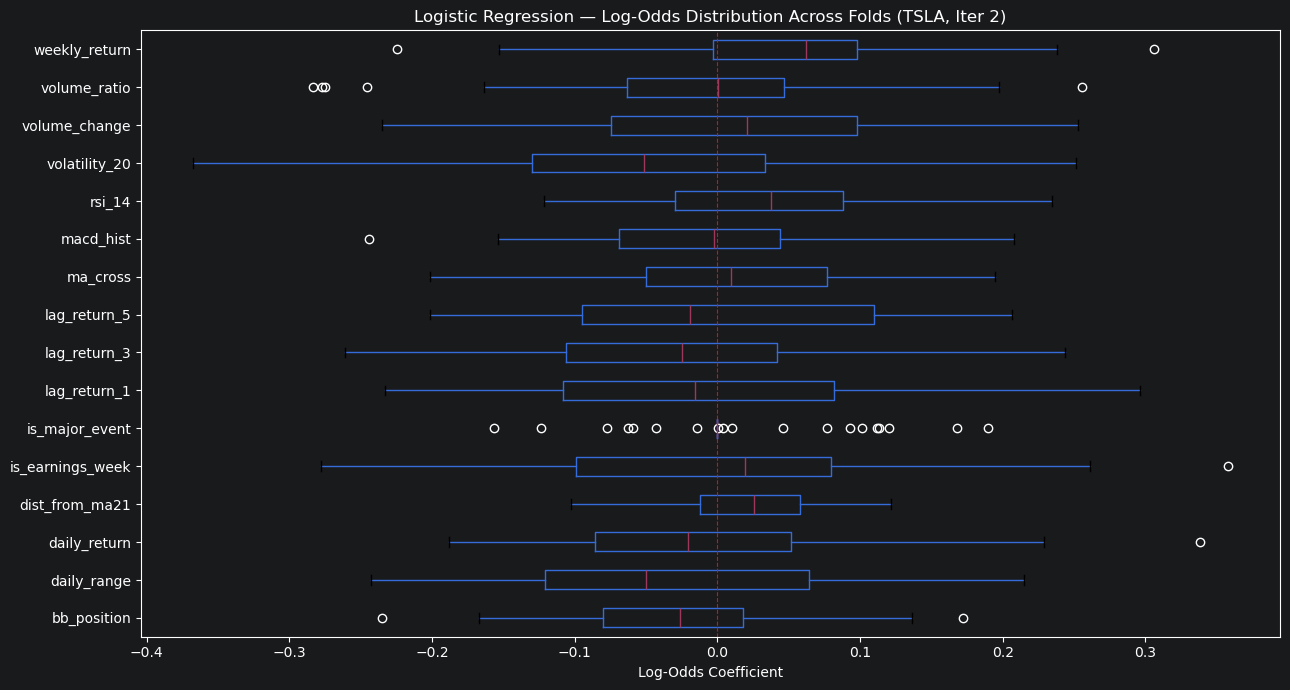

Saved: img/tsla_iter2_logistic_regression_coef_stability.png


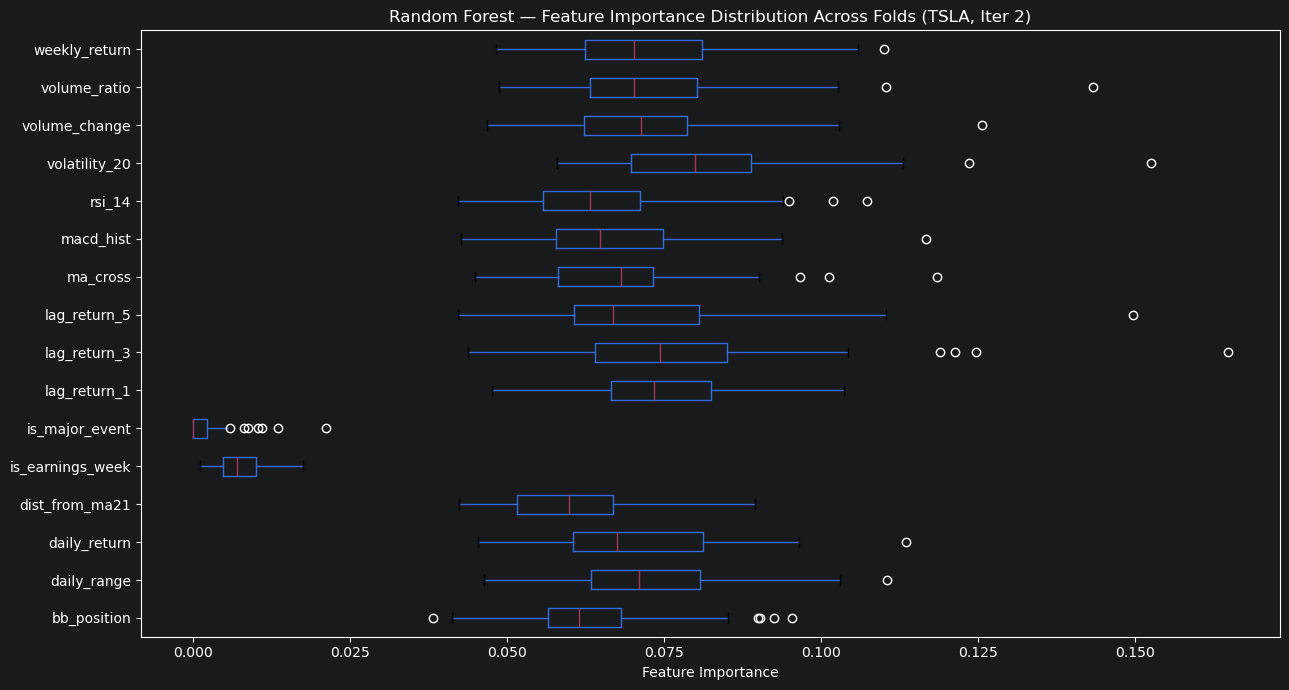

Saved: img/tsla_iter2_random_forest_coef_stability.png


In [8]:
# TSLA — LOGISTIC REGRESSION: Coefficient (Log-Odds) Stability Across Folds
pivot = log_coefs.pivot(index="fold", columns="feature", values="value")
fig, ax = plt.subplots(figsize=(13, 7))
pivot.boxplot(ax=ax, vert=False, grid=False)
ax.axvline(x=0, color="red", linestyle="--", linewidth=0.8)
ax.set_title("Logistic Regression \u2014 Log-Odds Distribution Across Folds (TSLA, Iter 2)")
ax.set_xlabel("Log-Odds Coefficient")
plt.tight_layout()
plt.savefig("img/tsla_iter2_logistic_regression_coef_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/tsla_iter2_logistic_regression_coef_stability.png")

# TSLA — RANDOM FOREST: Feature Importance Stability Across Folds
pivot = rf_coefs.pivot(index="fold", columns="feature", values="value")
fig, ax = plt.subplots(figsize=(13, 7))
pivot.boxplot(ax=ax, vert=False, grid=False)
ax.set_title("Random Forest \u2014 Feature Importance Distribution Across Folds (TSLA, Iter 2)")
ax.set_xlabel("Feature Importance")
plt.tight_layout()
plt.savefig("img/tsla_iter2_random_forest_coef_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/tsla_iter2_random_forest_coef_stability.png")